# Decision Tree


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
db = pd.read_csv('standardized_crops.csv')
db

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple
...,...,...,...,...,...,...,...,...
6591,60,30,30,1.180000,83.345432,6.500000,241.780000,Wheat (Gehun)
6592,60,30,30,12.500000,78.695522,6.500000,140.520000,Wheat (Gehun)
6593,60,30,30,14.600000,81.260205,6.400000,169.820000,Wheat (Gehun)
6594,60,30,30,16.820000,70.430798,6.900000,9.627044,Wheat (Gehun)


In [8]:
db.shape
db.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple


In [10]:
db.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [11]:
db.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,6596.000000,6596.000000,6596.000000,6596.000000,6596.000000,6596.000000,6596.000000
mean,65.334900,48.164494,50.290024,25.397240,73.407185,5.862800,531.003576
std,45.431015,23.699351,39.812887,5.052873,17.588425,0.756141,599.989529
min,0.000000,5.000000,5.000000,1.180000,14.258040,3.504752,3.274569
25%,26.000000,35.000000,20.000000,22.676000,61.251404,5.340000,89.740866
50%,50.000000,48.000000,39.000000,26.002745,81.209600,5.680000,199.212500
75%,90.000000,60.000000,65.000000,28.545455,85.612917,6.379911,942.800000
max,180.000000,145.000000,205.000000,43.675493,99.981876,9.935091,3322.060000


In [12]:
db.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [13]:
db.nunique()

N               139
P               118
K                80
temperature    2296
humidity       5292
ph             2282
rainfall       2297
label            51
dtype: int64

In [14]:
db['label'].value_counts()

label
Potato (Aloo)                   461
Onion (Pyaaz)                   383
Jowar (Sorghum)                 367
Sunflower (Surajmukhi)          362
Rapeseed (Sarson)               361
Ragi (Finger Millet)            293
Horse Gram (Kulthi)             272
Wheat (Gehun)                   264
Turmeric (Haldi)                259
Sweet Potato (Shakarkandi)      241
Soybean (Soyabean)              196
Barley (Jau)                    192
Coriander (Dhania)              190
Garlic (Lehsun)                 180
Apple                           100
Banana                          100
Black Gram (Urad)               100
Chickpea (Gram)                 100
Coconut (Nariyal)               100
Coffee                          100
Cotton (Kapash)                 100
Grapes                          100
Jute                            100
Kidney Beans (Rajma)            100
Lentil (Masoor)                 100
Maize (Corn)                    100
Mango                           100
Moth Beans            

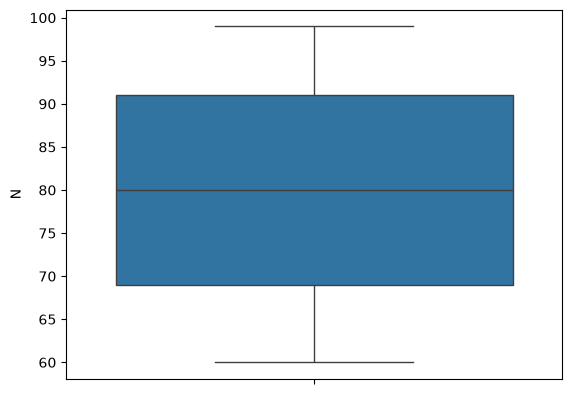

In [18]:
sns.boxplot(
    data=db[db["label"] == "Rice"],
    y="N"
)

plt.show()

<Axes: xlabel='N', ylabel='label'>

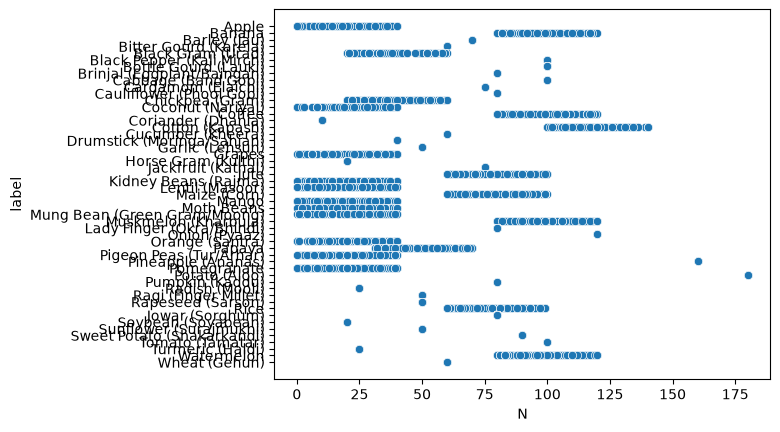

In [19]:
sns.scatterplot(data=db,x='N',y='label')

In [3]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
model = DecisionTreeClassifier(random_state=42,criterion="log_loss")
scaler = StandardScaler()


X = db.drop("label",axis=1)
y = db['label']

X_train, X_test, y_train,y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)



model.fit(X_train,y_train)

predictions = model.predict(X_test)
acc_score = accuracy_score(y_test,predictions)
c_report = classification_report(y_test,predictions,zero_division=0)
cm = confusion_matrix(y_test,predictions)

print("Accuracy : ", acc_score)
print("classification report :", c_report)



Accuracy :  0.9946969696969697
classification report :                               precision    recall  f1-score   support

                       Apple       1.00      1.00      1.00        25
                      Banana       1.00      1.00      1.00        21
                Barley (Jau)       0.98      1.00      0.99        48
       Bitter Gourd (Karela)       1.00      1.00      1.00         1
           Black Gram (Urad)       1.00      1.00      1.00        25
   Black Pepper (Kali Mirch)       0.94      1.00      0.97        16
        Bottle Gourd (Lauki)       1.00      1.00      1.00         2
  Brinjal (Eggplant/Baingan)       1.00      1.00      1.00        10
         Cabbage (Band Gobi)       1.00      1.00      1.00         2
          Cardamom (Elaichi)       1.00      1.00      1.00         8
    Cauliflower (Phool Gobi)       1.00      1.00      1.00         3
             Chickpea (Gram)       1.00      1.00      1.00        21
           Coconut (Nariyal)      

In [40]:
train_acc = model.score(X_train,y_train)
test_acc = model.score(X_test,y_test)

depth = model.get_depth()

print("Training accuracy : ", train_acc)
print("Testing accuracy :", test_acc)
print("Depth : ", depth)

Training accuracy :  1.0
Testing accuracy : 0.9840909090909091
Depth :  17


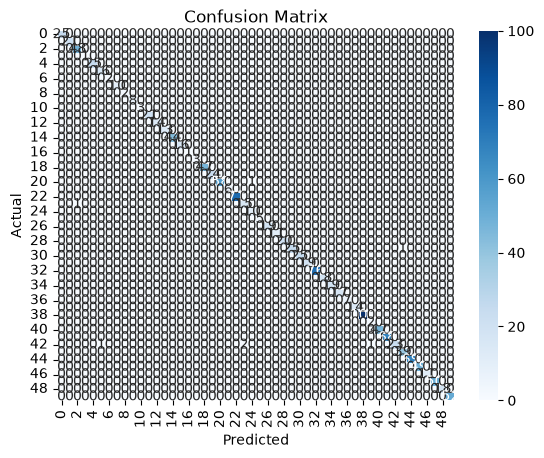

In [45]:
cm = confusion_matrix(y_test,predictions)


sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [7]:

new_data = pd.DataFrame([{
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.8,
    "humidity": 82,
    "ph": 6.5,
    "rainfall": 202.9
}])

prediction = model.predict(new_data)
probability = model.predict_proba(new_data)

print("Predicted crop:", prediction[0])
print("Probabilities:", probability[0])

Predicted crop: Rice
Probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0.]


In [8]:
probability = model.predict_proba(new_data)[0]

for crop, prob in zip(model.classes_, probability):
    if prob > 0:
        print(f"{crop}: {prob:.2f}")

Rice: 1.00


In [9]:
new_data = pd.DataFrame([{
    "N" : 24,
    "P" :128,
    "K" : 196,
    "temperature": 22.75088787,
    "humidity": 90.69489172,
    "ph": 5.521466996,
    "rainfall": 110.4317855
}])

prediction = model.predict(new_data)
prediction

array(['Apple'], dtype=object)